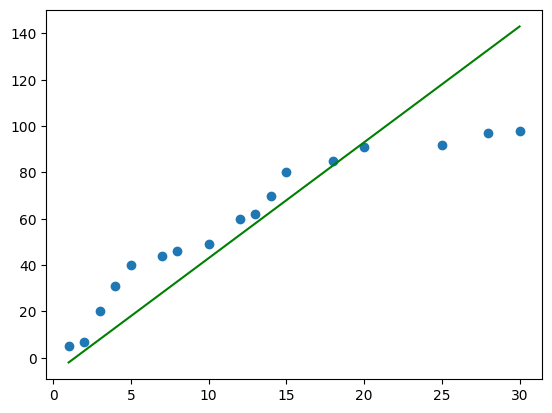

In [8]:
# 독립변수 1개, 종속변수 1개로 데이터를 생성
# 공부시간에 따른 시험 성적(연속적인 숫자값을 label로 사용)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    '공부시간(x)' : [1,2,3,4,5,7,8,10,12,13,14,15,18,20,25,28,30],
    '시험성적(t)' : [5,7,20,31,40,44,46,49,60,62,70,80,85,91,92,97,98]
})

# display(df)
plt.scatter(df['공부시간(x)'], df['시험성적(t)'])
# plt.plot(df['공부시간(x)'], df['공부시간(x)'] * 2 + 3, color='r')  # y = 2x + 3
plt.plot(df['공부시간(x)'], df['공부시간(x)'] * 5 - 7, color='g')  # y = 5x - 7
# plt.plot(df['공부시간(x)'], df['공부시간(x)'] * 1 + 8, color='b')  # y = x + 8
# plt.plot(df['공부시간(x)'], df['공부시간(x)'] * 4 - 10, color='magenta')  # y = 4x - 10
plt.show()

In [ ]:
# 독립변수가 1개인 상태에서
# 기본 모델인 classical linear regression model을 적용하면


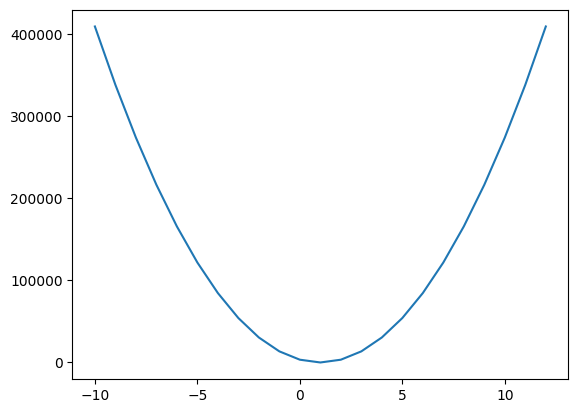

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# training data set
x = np.arange(1,101)
t = np.arange(1,101)

W = np.arange(-10,13)

loss = []

for tmp in W:
      # 평균제곱오차
    loss.append(np.power(t - tmp*x,2).mean())

plt.plot(W, loss)
plt.show()

In [13]:
import numpy as np

def numerical_derivative(f,x):
    # f : 미분을 하려는 함수(다변수 함수)
    # x : 모든 변수를 포함하고 있는 ndarray(차원 무관) [1.0, 2.0]
    delta_x = 0.0001
    derivative_x = np.zeros(x.shape)  # [0.0, 0.0]

    # iterator를 하나 생성해요!
    it = np.nditer(x, flags=['multi_index'])

    while not it.finished:
        idx = it.multi_index  # (0,)  (1,)

        tmp = x[idx]  # 첫번째 index에 대한 값을 임시로 저장(1.0)

        x[idx] = tmp + delta_x  # [1.0001, 2.0]

        fx_plus_delta = f(x) # f(x + delta_x)

        x[idx] = tmp - delta_x # [0.9999, 2.0]

        fx_minus_delta = f(x) # f(x - delta_x)

        derivative_x[idx] = (fx_plus_delta-fx_minus_delta) / (2*delta_x)

        x[idx] = tmp

        it.iternext()

    return derivative_x

In [17]:
# python코드로 간단한 Simple Linear Regression을 구현해 볼거예요!
# Simple : 독립변수가 1개
# Linear : 종속변수의 값이 연속적인 실수값.
# Regression 모델 구현

import numpy as np

# Raw Data Loading
# 당연히 데이터 전처리를 진행.
# => 양질의(학습에 문제가 없는) 데이터를 확보
# Training Data Set을 준비
x_data = np.array([1,2,3,4,5]).reshape(-1,1)
t_data = np.array([3,5,7,9,11]).reshape(-1,1)

# Weight, Bias를 정의
# W는 독립변수가 1개이기 때문에 1개의 값을 가지고
# 형태은 2차원 matrix가 되어야 하며 초기값은 랜덤하게 생성
W = np.random.rand(1,1) # 0부터 1사이의 균등분포에서 실수를 생성. 1행1열로 생성
b = np.random.rand(1)

# 수치미분 코드가 나와야 해요!(위쪽 셀에 있어요!)

# 미분할 함수가 나와야 해요!(우리 문제에서 미분의 대상은 당연히 loss)
def loss_func(input_obj):   # input_obj : [w b]
    # MSE를 이용해서 우리는 loss를 사용하고 있어요!
    # 평균제곱오차를 구하는 코드를 작성해야 해요!
    input_W = input_obj[0].reshape(-1,1)
    input_b = input_obj[1].reshape(-1,1)

    y = np.dot(x_data,input_W) + input_b

    return np.mean(np.power(t_data-y,2))

# 예측 함수
# 모델이 완성된 다음 알고 싶은값을 모델에 넣어서 결과값을 확인하기 위한
# 용도로 사용
def predict(x):
    y = np.dot(x,W) + b
    return y

# learning_rate 값 정의
learning_rate = 1e-4

# 준비된 구성요소들을 이용해서 로직을 실행
# 반복적으로 학습을 진행!

# 반복횟수도 hyper parameter
for step in range(300000):

    # 미분을 할건데 대상이 되는 함수는 loss함수예요!
    # 미분을 수행할 W값과 b값을 인자로 미분을 수행해야 해요!
    input_param = np.concatenate((W.ravel(),b.ravel()),axis=0)  # [W b]
    derivative_result = learning_rate * numerical_derivative(loss_func, input_param)

    W = W - derivative_result[0].reshape(-1,1)  # 개선된 W를 구할 수 있어요!
    b = b - derivative_result[1]

    if step % 30000 == 0:
        print(f'현재의 W값은 : {W}')

# 우리 모델이 완성되었을 테니 이제 예측을 해 보면 되겠죠!~
predict_result = predict(np.array([[7]]))
print(predict_result)  # 15....

현재의 W값은 : [[0.26083514]]
현재의 W값은 : [[1.99444785]]
현재의 W값은 : [[1.99798649]]
현재의 W값은 : [[1.99926979]]
현재의 W값은 : [[1.99973519]]
현재의 W값은 : [[1.99990396]]
현재의 W값은 : [[1.99996517]]
현재의 W값은 : [[1.99998737]]
현재의 W값은 : [[1.99999542]]
현재의 W값은 : [[1.99999834]]
[[14.99999796]]


In [30]:
# 이번에는 Ozone.csv를 이용해서 Simple Linear Regression을 구현하고
# 그 결과를 그래프로 그려보아요!
# python코드로 간단한 Simple Linear Regression을 구현해 볼거예요!
# Simple : 독립변수가 1개
# Linear : 종속변수의 값이 연속적인 실수값.
# Regression 모델 구현

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Raw Data Loading
ozone = pd.read_csv('/content/ozone.csv')
# display(ozone)

df = ozone[['Temp','Ozone']]
# display(df)
new_df = df.dropna(inplace=False, how='any')
# 당연히 데이터 전처리를 진행.
# => 양질의(학습에 문제가 없는) 데이터를 확보
# 결측치 처리만 하고 나머지 처리는 지금 하지 않을꺼예요!!

# Training Data Set을 준비
x_data = new_df['Temp'].values.reshape(-1,1)
t_data = new_df['Ozone'].values.reshape(-1,1)

# Weight, Bias를 정의
# W는 독립변수가 1개이기 때문에 1개의 값을 가지고
# 형태은 2차원 matrix가 되어야 하며 초기값은 랜덤하게 생성
W = np.random.rand(1,1) # 0부터 1사이의 균등분포에서 실수를 생성. 1행1열로 생성
b = np.random.rand(1)

# 수치미분 코드가 나와야 해요!(위쪽 셀에 있어요!)

# 미분할 함수가 나와야 해요!(우리 문제에서 미분의 대상은 당연히 loss)
def loss_func(input_obj):   # input_obj : [w b]
    # MSE를 이용해서 우리는 loss를 사용하고 있어요!
    # 평균제곱오차를 구하는 코드를 작성해야 해요!
    input_W = input_obj[0].reshape(-1,1)
    input_b = input_obj[1].reshape(-1,1)

    y = np.dot(x_data,input_W) + input_b

    return np.mean(np.power(t_data-y,2))

# 예측 함수
# 모델이 완성된 다음 알고 싶은값을 모델에 넣어서 결과값을 확인하기 위한
# 용도로 사용
def predict(x):
    y = np.dot(x,W) + b
    return y

# learning_rate 값 정의
learning_rate = 1e-4

# 준비된 구성요소들을 이용해서 로직을 실행
# 반복적으로 학습을 진행!

# 반복횟수도 hyper parameter
for step in range(300000):

    # 미분을 할건데 대상이 되는 함수는 loss함수예요!
    # 미분을 수행할 W값과 b값을 인자로 미분을 수행해야 해요!
    input_param = np.concatenate((W.ravel(),b.ravel()),axis=0)  # [W b]
    derivative_result = learning_rate * numerical_derivative(loss_func, input_param)

    W = W - derivative_result[0].reshape(-1,1)  # 개선된 W를 구할 수 있어요!
    b = b - derivative_result[1]

    if step % 30000 == 0:
        print(f'현재의 W값은 : {W}')

# 우리 모델이 완성되었을 테니 이제 예측을 해 보면 되겠죠!~
predict_result = predict(np.array([[75]]))
print(predict_result)  # [[38.29876606]]

현재의 W값은 : [[0.56378957]]
현재의 W값은 : [[0.72108291]]
현재의 W값은 : [[0.86331417]]
현재의 W값은 : [[0.99369868]]
현재의 W값은 : [[1.1132232]]
현재의 W값은 : [[1.22279227]]
현재의 W값은 : [[1.32323511]]
현재의 W값은 : [[1.41531186]]
현재의 W값은 : [[1.49971934]]
현재의 W값은 : [[1.57709634]]
[[38.29243807]]


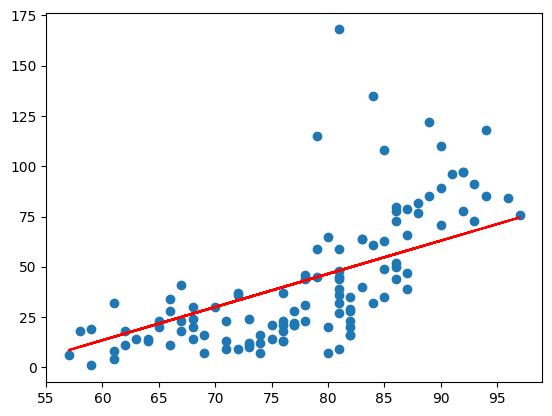

In [31]:
# 일단 데이터의 분포부터 한번 확인하고 갈꺼예요!
plt.scatter(new_df['Temp'].values,
            new_df['Ozone'].values)
plt.plot(new_df['Temp'].values,
         new_df['Temp'].values * W.ravel() + b,
         color='red')
plt.show()

In [27]:
# 만들어진 모델에 대한 그래프를 살펴봤는데
# 그럴듯해요... 하지만 이 모델이 최적의 모델인지는 알 수 없어요
# 당연히 모델의 검증과정은 필요해요!~

# 하지만 지금은 그 검증을 진행하기가 어려우니
# 이미 잘 만들어진 모델을 가져다가 학습하고 우리 모델과 비교해서
# 우리 모델이 잘 만들어졌는지 확인!

In [29]:
# sklearn을 이용해서 정답에 근사한 모델을 구현하고
# 모델에 대한 그래프를 그려볼꺼예요!
from sklearn import linear_model

# model을 만들어 보아요!
sklearn_model = linear_model.LinearRegression()

# 데이터를 이용해서 모델을 학습
sklearn_model.fit(x_data,
                  t_data)

# 모델을 완성했다는 말은 W와 b를 구했다는 얘기예요!
print(f'W의 값은 : {sklearn_model.coef_}, b의 값은 {sklearn_model.intercept_}')

# 모델이 완성되었으니.. 75도에 대한 예측 오존량을 알아보아요!
print(sklearn_model.predict(np.array([[75]])))  # [[35.15725689]]


W의 값은 : [[2.4287033]], b의 값은 [-146.99549097]
[[35.15725689]]


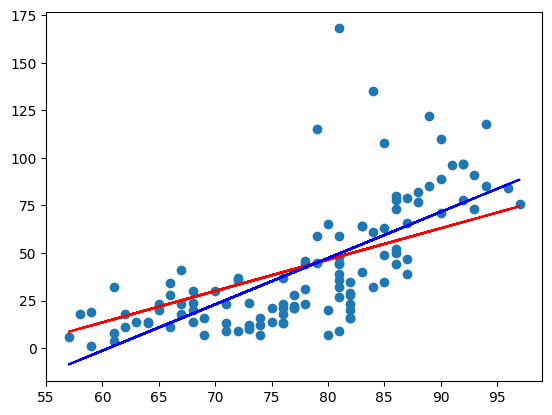

In [32]:
plt.scatter(new_df['Temp'].values,
            new_df['Ozone'].values)
plt.plot(new_df['Temp'].values,
         new_df['Temp'].values * W.ravel() + b,
         color='red')
plt.plot(new_df['Temp'].values,
         new_df['Temp'].values * sklearn_model.coef_.ravel() + sklearn_model.intercept_,
         color='blue')
plt.show()